# Project - Ethics of AI
## | Make Ethical a Classic AI Workflow |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Problematic 
Identify the criticity of tickets from customer demand of support

In [2]:
df = pd.read_csv("../data/Loan.csv")
df.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [14]:
# Casting data
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'], format='%Y-%m-%d')

In [12]:
df.shape

(20000, 36)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ApplicationDate             20000 non-null  datetime64[ns]
 1   Age                         20000 non-null  int64         
 2   AnnualIncome                20000 non-null  int64         
 3   CreditScore                 20000 non-null  int64         
 4   EmploymentStatus            20000 non-null  object        
 5   EducationLevel              20000 non-null  object        
 6   Experience                  20000 non-null  int64         
 7   LoanAmount                  20000 non-null  int64         
 8   LoanDuration                20000 non-null  int64         
 9   MaritalStatus               20000 non-null  object        
 10  NumberOfDependents          20000 non-null  int64         
 11  HomeOwnershipStatus         20000 non-null  object    

In [6]:
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [ ]:
"""
EDA :

About the dataset :
    Each row represent a client profile
    Data has been collected by banks

Visualization :
    Future univariate visualizations :
        - Distribution de l'age : Histogram
        - Annual Income : Histogram
        - EducationLevel : Bar Chart
        - MaritalStatus : BarChart / Cheese
    Future bivariate visualizations :
        - Heatmap of correlation(Age, Experience, AnnualIncome, CreditScore)
        - Chi-square test for dependence
"""

In [ ]:
df['Date of Purchase'] = pd.to_datetime(df["ApplicationDate"])
df['First Response Time'] = pd.to_datetime(df["First Response Time"])
df['Time to Resolution'] = pd.to_datetime(df["Time to Resolution"])


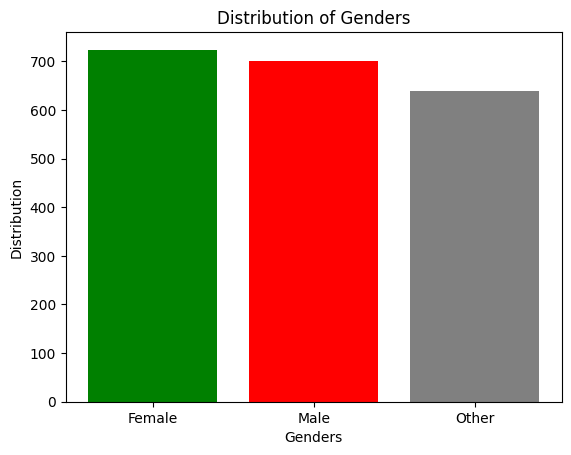

In [31]:
mask = df["Ticket Priority"]=='Low'
counts = df[mask]["Customer Gender"].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Distribution of Genders")
plt.xlabel("Genders")
plt.ylabel("Distribution")

plt.bar(counts.index, counts.values, color=["green", "red", "gray"])

plt.show()


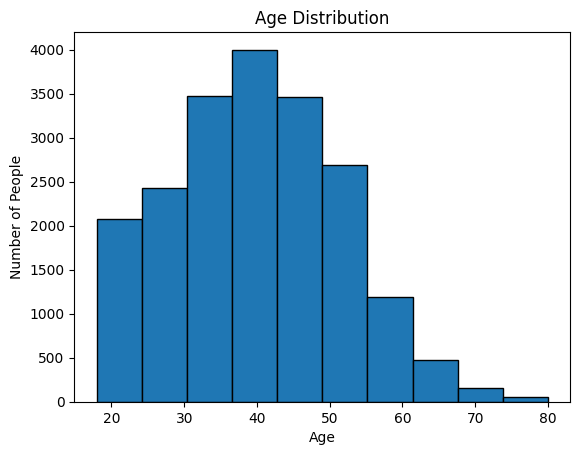

In [3]:
plt.hist(df["Age"], bins=10, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()

In [19]:
date_purchase = df['Date of Purchase'].value_counts().sort_index()
date_fresponse = df['First Response Time'].value_counts().sort_index()
date_resolution = df['Time to Resolution'].value_counts().sort_index()


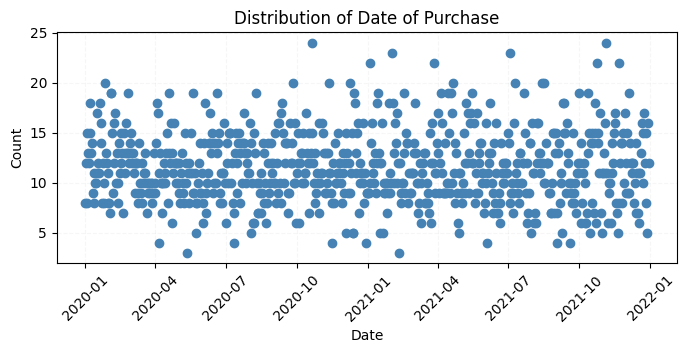

In [20]:
plt.figure(figsize=(8, 3))
plt.plot(date_purchase.index, date_purchase.values, 'o', color='steelblue')

plt.title("Distribution of Date of Purchase")
plt.xlabel("Date")
plt.ylabel("Count")
plt.grid(True, linestyle="--", alpha=0.1)
plt.xticks(rotation=45)
plt.show()

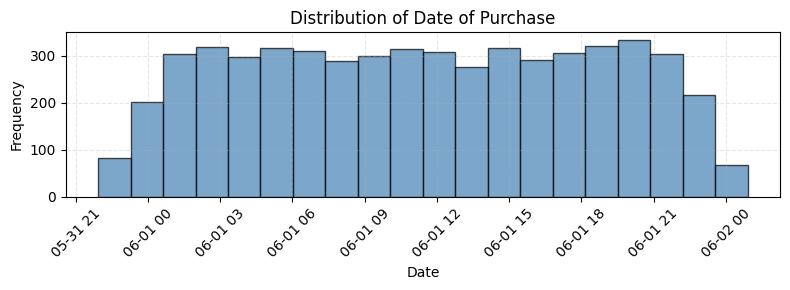

In [ ]:
plt.figure(figsize=(8, 3))
plt.hist(date_fresponse.index, bins=20, color='steelblue', edgecolor='black', alpha=0.7)

plt.title("Distribution of First Response")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

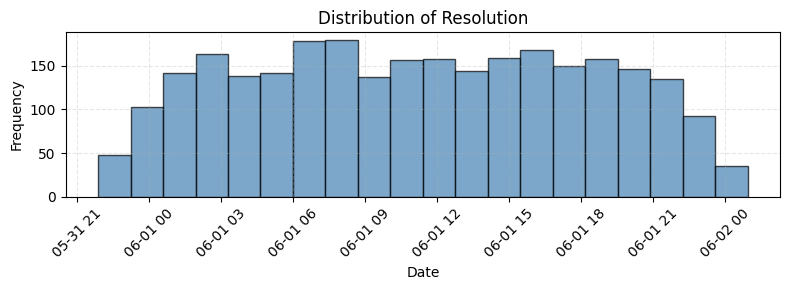

In [26]:
plt.figure(figsize=(8, 3))
plt.hist(date_resolution.index, bins=20, color='steelblue', edgecolor='black', alpha=0.7)

plt.title("Distribution of Resolution")
plt.xlabel("Date")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

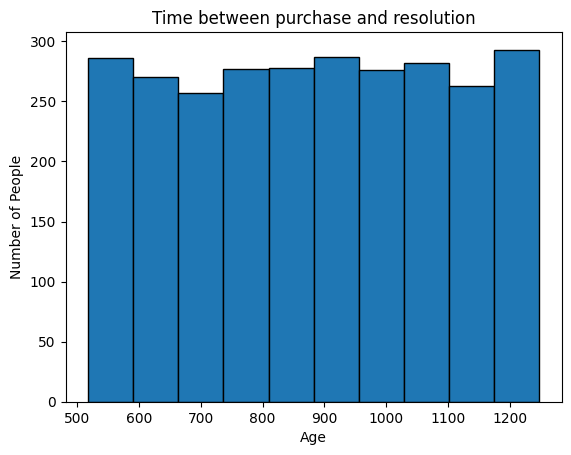

In [33]:
temp = df.copy()
temp['time_btw'] = (df["Time to Resolution"] - df["Date of Purchase"]).dt.days

plt.hist(temp["time_btw"], bins=10, edgecolor="black")

plt.title("Time between purchase and resolution")
plt.xlabel("Age")
plt.ylabel("Number of People")

plt.show()
